# SOB4ES - RegressorChain (Random Forest base)

### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluación de los modelos

Este notebook implementa un **RegressorChain** usando Random Forest como modelo base.

La idea es encadenar las predicciones: el modelo primero predice el target 1, luego usa esa predicción junto a las variables originales para predecir el target 2, y así sucesivamente. 

Esto introduce correlacion real entre targets: cada predicción tiene acceso a las predicciones anteriores en la cadena.

El problema del encadenamiento simple es que los targets al principio de la cadena tienen menos información que los del final. Para compensarlo se usa un **ensemble de cadenas** donde cada cadena usa un orden diferente y aleatorio de los targets. 

Al promediar los resultados, los errores acumulados por el orden se cancelan entre sí.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por país)
- `test.csv` - Búsqueda de hiperparámetros y validación cruzada (15 %)
- `eval.csv` - Evaluación final e imparcial del rendimiento (15 %)  

**Estructura del notebook:**
1. **Configuración:** importaciones y parámetros globales.
2. **Carga de datos:** se cargan los tres splits pre-generados.
3. **Tuning del modelo base:** búsqueda del valor óptimo de los hiperparámetros.
4. **Validación cruzada:** evaluación de robustez.
5. **Análisis de la cadena:** importancia de variables y orden
6. **Producción:** entrenamiento final y exportación de modelos.
7. **Evaluación final:** rendimiento real sobre `eval.csv`.

## 1.- Configuración del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import itertools

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import RegressorChain
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import shap

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/chain/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

N_CHAINS = 10  # numero de cadenas en el ensemble; mas cadenas = mas estable pero mas lento
RANDOM_STATE = 128

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas.')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas.


In [2]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)
import os

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 20 | n_jobs asignado: 15


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la división 70/15/15 estratificada por país.

| Archivo     | Uso                                      | Filas aprox. |
| ----------- | ---------------------------------------- | ------------ |
| `train.csv` | Ajuste del modelo                        | 299          |
| `test.csv`  | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv`  | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimación imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print('Cargando datasets...')
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
X_test  = df_test[FEATURES_AUTORIZADAS]
X_eval  = df_eval[FEATURES_AUTORIZADAS]

# y es una matriz 2D (n_muestras x n_targets) para todos los modelos de esta fase
y_train = df_train[TARGETS]
y_test  = df_test[TARGETS]
y_eval  = df_eval[TARGETS]

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Tuning del modelo base

`RegressorChain` encapsula un modelo base que se replica una vez por target. 

El tuning se hace sobre ese modelo base (Random Forest individual) usando un único target de referencia. Los parámetros óptimos se usarán para construir cada cadena del ensemble.

**Nota:** el tuning del modelo base es suficiente porque `RegressorChain` no tiene hiperparámetros propios más allá del orden de la cadena, que se aleatoriza en el entrenamiento.

Iniciando busqueda de hiperparametros del modelo base...
La busqueda evalua el R2 promedio sobre los 21 targets simultaneamente (no solo 2 de referencia).



Busqueda completada en 0.1 minutos.
Mejor R2 promedio (21 targets, CV 5-fold): 0.1608

Hiperparametros optimos del modelo base:
  random_state: 128
  n_estimators: 200
  min_samples_split: 15
  min_samples_leaf: 2
  max_samples: 0.8
  max_features: 0.2
  max_depth: 20
  ccp_alpha: 0.01
  bootstrap: True
  n_jobs: 15

R2 individual por target (mismo modelo base, CV 5-fold):


  nematode_shannon_z             0.1987


  macro_shannon_z                0.2824


  earthworm_shannon_z            0.4426


...

  bac_asv_richness_z             0.0873


  fun_asv_richness_z             -0.0591


  euk_asv_richness_z             0.2199


  oomy_asv_richness_z            0.2385


  cerc_asv_richness_z            0.1900


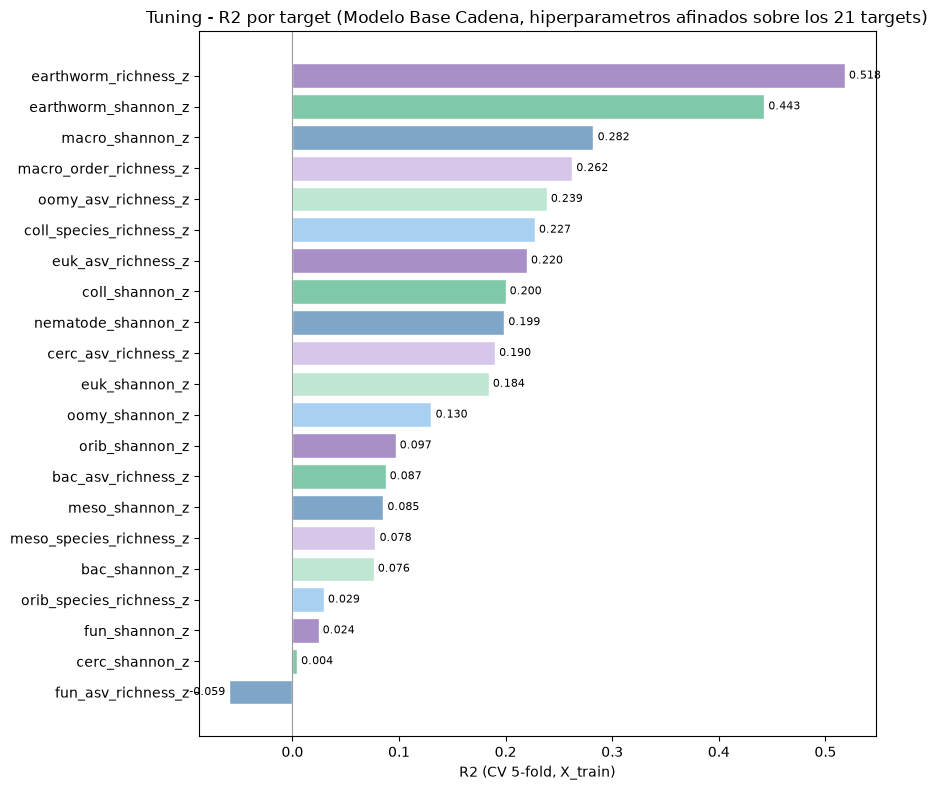

In [4]:
print('Iniciando busqueda de hiperparametros del modelo base...')
print('La busqueda evalua el R2 promedio sobre los 21 targets simultaneamente (no solo 2 de referencia).\n')

# Espacio de busqueda ampliado
param_grid_frenado = {
	'n_estimators':      [100, 150, 200],
	'max_depth':         [3, 4, 5, 10, 15, 20],
	'min_samples_leaf':  [2, 4, 8, 12, 16],
	'min_samples_split': [15, 20, 25],
	'max_features':      ['sqrt', 0.2, 0.3],
	'max_samples':       [0.7, 0.8],
	'ccp_alpha':         [0.005, 0.01, 0.02],
	'bootstrap':         [True],
	'random_state':      [RANDOM_STATE]
}

start_total = time.time()

# RandomForestRegressor admite y multivariante de forma nativa: al pasarle
# y_train completo (21 columnas), el scoring 'r2' de sklearn calcula el
# R2 de cada target y devuelve el promedio (multioutput='uniform_average').
buscador = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_grid_frenado,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=0,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)
buscador.fit(X_train, y_train)
elapsed = (time.time() - start_total) / 60

BASE_PARAMS = dict(buscador.best_params_)
BASE_PARAMS['random_state'] = RANDOM_STATE
BASE_PARAMS['n_jobs'] = N_JOBS

print(f'Busqueda completada en {elapsed:.1f} minutos.')
print(f'Mejor R2 promedio (21 targets, CV 5-fold): {buscador.best_score_:.4f}\n')
print('Hiperparametros optimos del modelo base:')
for k, v in BASE_PARAMS.items():
    print(f'  {k}: {v}')

# R2 individual por target del mejor modelo encontrado, para ver que tan
# representativo es el consenso de hiperparametros para cada variable objetivo
print('\nR2 individual por target (mismo modelo base, CV 5-fold):')
r2_por_target_base = {}
for target_col in TARGETS:
    scores = cross_validate(
        RandomForestRegressor(**BASE_PARAMS),
        X_train, y_train[target_col].values,
        cv=5, scoring='r2'
    )['test_score']
    r2_por_target_base[target_col] = np.mean(scores)
    print(f'  {target_col:30} {r2_por_target_base[target_col]:.4f}')

# Grafico: R2 por target del modelo base ya afinado
r2_series = pd.Series(r2_por_target_base).sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
_bars = ax.barh(r2_series.index, r2_series.values,
                 color=palette_cycle(len(r2_series)), edgecolor='white')
ax.bar_label(_bars, fmt='{:.3f}', padding=3, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - R2 por target (Modelo Base Cadena, hiperparametros afinados sobre los 21 targets)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4.- Validación cruzada

Se evalua la robustez de una cadena única (orden por defecto) con **validación cruzada repetida** (5 pliegues x 3 repeticiones) sobre `X_train`. 

El ensemble de cadenas aleatorias que se entrena en producción será más robusto que esta cadena única, por lo que estos resultados son una estimacióon conservadora del rendimiento final.

In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedKFold, cross_validate

print('Validacion cruzada repetida (Modelos Independientes + Seleccion de Variables)...\n')

# Número de mejores predictores a conservar individualmente por target
K_BEST_FEATURES = 8

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
resultados_cv_por_target = {}

header = f"{'TARGET':<26} | {'TRAIN R2':<10} | {'CV R2':<10} | {'DIFF':<10} | {'ESTADO'}"
print(header)
print('-' * len(header))

for target_col in TARGETS:
    y_target = y_train[target_col].values

    # Opción B: Obtener hiperparámetros específicos del target de forma segura
    params_target = BASE_PARAMS.get(target_col, BASE_PARAMS)

    # Pipeline individual: Filtrado de características + Random Forest regularizado
    pipeline_modelo = Pipeline([
        ('selector', SelectKBest(score_func=f_regression, k=K_BEST_FEATURES)),
        ('rf', RandomForestRegressor(
            **params_target
        ))
    ])

    resultados = cross_validate(
        estimator=pipeline_modelo,
        X=X_train,
        y=y_target,
        cv=cv_splitter,
        scoring=['r2'],
        return_train_score=True,
        n_jobs=N_JOBS
    )

    r2_train   = np.mean(resultados['train_r2'])
    r2_cv      = np.mean(resultados['test_r2'])
    diferencia = r2_train - r2_cv

    resultados_cv_por_target[target_col] = {'train_r2': r2_train, 'cv_r2': r2_cv}

    estado = "Aviso: Posible sobreajuste" if diferencia > 0.15 else "OK"

    print(f"{target_col:<26} | {r2_train:<10.3f} | {r2_cv:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida (Modelos Independientes + Seleccion de Variables)...

TARGET                     | TRAIN R2   | CV R2      | DIFF       | ESTADO
--------------------------------------------------------------------------


nematode_shannon_z         | 0.465      | 0.204      | 0.261      | Aviso: Posible sobreajuste


macro_shannon_z            | 0.463      | 0.137      | 0.326      | Aviso: Posible sobreajuste


earthworm_shannon_z        | 0.567      | 0.340      | 0.227      | Aviso: Posible sobreajuste


orib_shannon_z             | 0.418      | 0.088      | 0.331      | Aviso: Posible sobreajuste


...

bac_asv_richness_z         | 0.377      | 0.045      | 0.332      | Aviso: Posible sobreajuste


fun_asv_richness_z         | 0.331      | -0.036     | 0.366      | Aviso: Posible sobreajuste


euk_asv_richness_z         | 0.469      | 0.163      | 0.306      | Aviso: Posible sobreajuste


oomy_asv_richness_z        | 0.477      | 0.181      | 0.296      | Aviso: Posible sobreajuste


cerc_asv_richness_z        | 0.474      | 0.180      | 0.294      | Aviso: Posible sobreajuste


## 5.- Análisis de la cadena

Se analiza el efecto del orden de la cadena en el rendimiento por target. Los targets al principio de la cadena solo tienen acceso a las variables originales, mientras que los del final tienen además las predicciones de todos los anteriores.

Se muestra también la importancia de variables del modelo base para el primer target de la cadena, donde no hay predicciones previas disponibles y la dificultad es máxima.

Analisis del efecto del orden en la cadena...



  Posicion en cadena -> target -> R2 (train):
    Posicion  1 | nematode_shannon_z             R2: 0.5908
    Posicion  2 | macro_shannon_z                R2: 0.6294
    Posicion  3 | earthworm_shannon_z            R2: 0.7149
    Posicion  4 | orib_shannon_z                 R2: 0.5242
    Posicion  5 | meso_shannon_z                 R2: 0.4319
    Posicion  6 | coll_shannon_z                 R2: 0.5265
    Posicion  7 | bac_shannon_z                  R2: 0.3944
    Posicion  8 | fun_shannon_z                  R2: 0.4679
    Posicion  9 | euk_shannon_z                  R2: 0.5146
    Posicion 10 | oomy_shannon_z                 R2: 0.5267
    Posicion 11 | cerc_shannon_z                 R2: 0.3650
    Posicion 12 | macro_order_richness_z         R2: 0.6130
    Posicion 13 | earthworm_richness_z           R2: 0.7390
    Posicion 14 | orib_species_richness_z        R2: 0.4270
    Posicion 15 | meso_species_richness_z        R2: 0.3274
    Posicion 16 | coll_species_richness_z        R2: 0

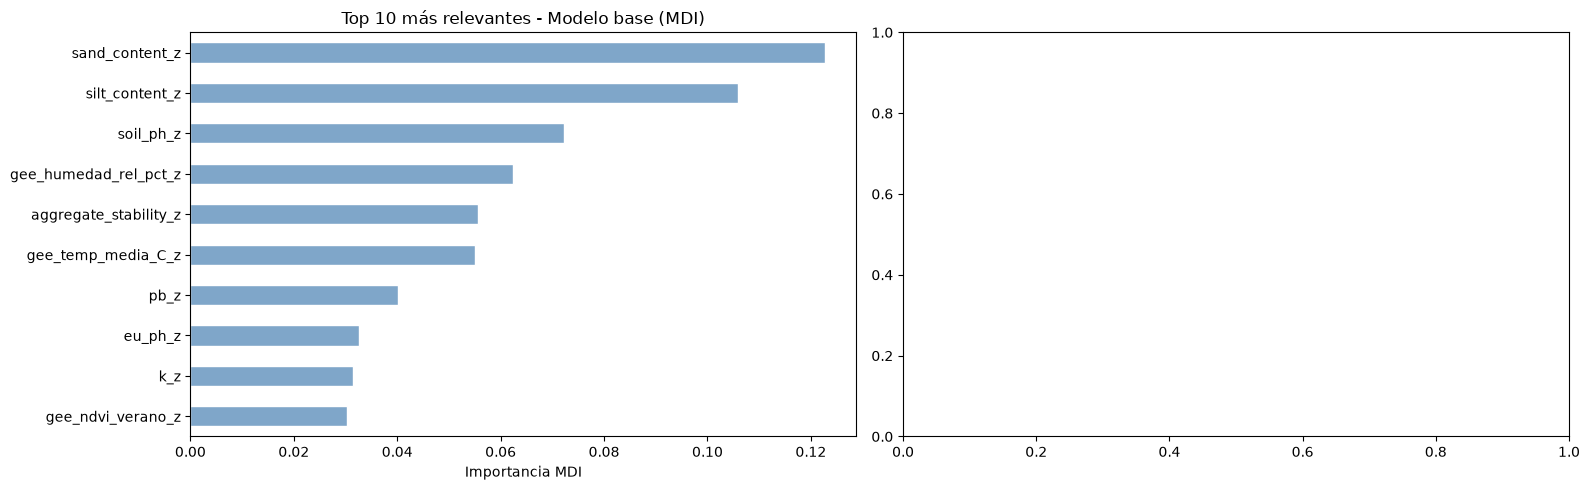


Gráfico SHAP summary plot (primer target):


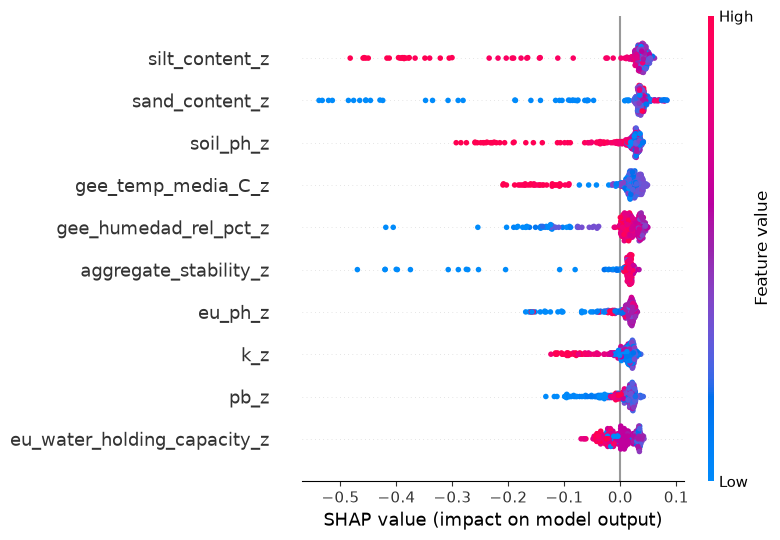

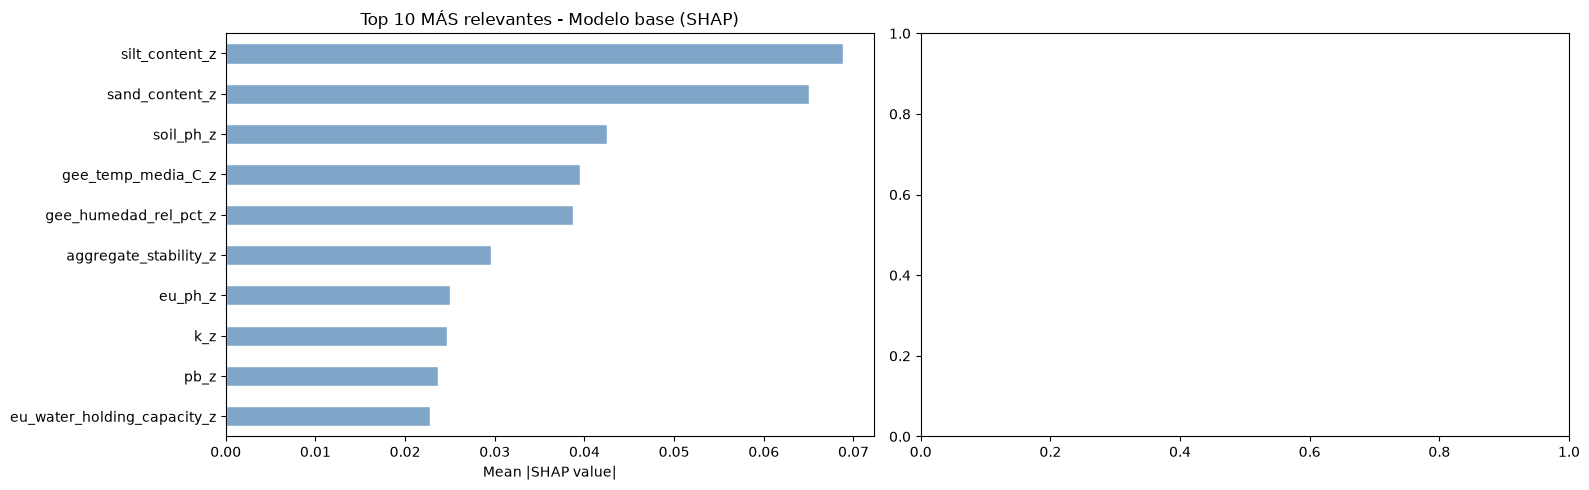

In [6]:
print('Analisis del efecto del orden en la cadena...\n')
# Cadena de referencia (orden por defecto) para este analisis -
# no depende de la celda de Validacion cruzada, que ya no entrena una cadena
cadena_cv = RegressorChain(RandomForestRegressor(**BASE_PARAMS), order=None)
cadena_cv.fit(X_train, y_train)
y_pred_train = cadena_cv.predict(X_train)

# 1. Evaluación por posición en la cadena
print('  Posicion en cadena -> target -> R2 (train):')
for i, t in enumerate(TARGETS):
    r2 = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
    print(f'    Posicion {i+1:2d} | {t:30} R2: {r2:.4f}')

# 2. Importancia MDI del modelo base (primer target)
primer_modelo = cadena_cv.estimators_[0]
imp_mdi = pd.Series(primer_modelo.feature_importances_, index=FEATURES_AUTORIZADAS)

top10_mdi = imp_mdi.nlargest(10)

print('\n  Top 10 variables más relevantes (MDI - Primer Target):')
print(top10_mdi.round(4).to_string())

# Gráficos comparativos MDI (Más vs Menos relevantes)
fig, axes_mdi = plt.subplots(1, 2, figsize=(16, 5))

top10_mdi.sort_values().plot(kind='barh', ax=axes_mdi[0], color=PALETTE['blue'], edgecolor='white')
axes_mdi[0].set_title('Top 10 más relevantes - Modelo base (MDI)', fontsize=12)
axes_mdi[0].set_xlabel('Importancia MDI')

plt.tight_layout()
plt.show()

# 3. Análisis SHAP del modelo base (primer target)
explainer   = shap.TreeExplainer(primer_modelo)
shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap_arr = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_arr = np.abs(shap_values).mean(axis=2)
else:
    shap_arr = shap_values

# Dot plot estándar SHAP
print('\nGráfico SHAP summary plot (primer target):')
shap.summary_plot(shap_arr, X_train, plot_type='dot', max_display=10)

# Importancia absoluta media SHAP por variable
mean_abs_shap = np.abs(shap_arr).mean(axis=0)
imp_shap = pd.Series(mean_abs_shap, index=FEATURES_AUTORIZADAS)

top10_shap = imp_shap.nlargest(10)

# Gráficos comparativos SHAP (Más vs Menos relevantes)
fig, axes_shap = plt.subplots(1, 2, figsize=(16, 5))

top10_shap.sort_values().plot(kind='barh', ax=axes_shap[0], color=PALETTE['blue'], edgecolor='white')
axes_shap[0].set_title('Top 10 MÁS relevantes - Modelo base (SHAP)', fontsize=12)
axes_shap[0].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.show()

## 6.- Entrenamiento

Se entrenan 10 cadenas con ordenes aleatorios distintos. 

Cada cadena usa el mismo modelo base (Random Forest con los hiperparámetros óptimos) pero un orden diferente de los targets.

Al promediar las predicciones de todas las cadenas, se compensan los errores de acumulación que afectan a los targets al principio de cada cadena.

In [7]:
print(f'Entrenamiento de produccion ({N_CHAINS} cadenas con ordenes aleatorios)...')
print('-' * 70)

global_start = time.time()
ordenes_usados = []

for chain_id in range(N_CHAINS):
    t0 = time.time()

    # Cada cadena usa un orden aleatorio distinto de los 11 targets
    orden = list(np.random.RandomState(RANDOM_STATE + chain_id).permutation(len(TARGETS)))
    ordenes_usados.append(orden)

    base_model = RandomForestRegressor(**{**BASE_PARAMS, 'random_state': RANDOM_STATE + chain_id})
    cadena     = RegressorChain(base_model, order=orden)
    cadena.fit(X_train, y_train)

    joblib.dump(cadena, os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl'))
    print(f'  Cadena {chain_id+1:2d}/{N_CHAINS} | orden: {orden} | ({time.time()-t0:.1f}s)')

# Guardamos los ordenes para referencia futura
joblib.dump(ordenes_usados, os.path.join(MODELS_DIR, 'ordenes.pkl'))

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')

Entrenamiento de produccion (10 cadenas con ordenes aleatorios)...
----------------------------------------------------------------------


  Cadena  1/10 | orden: [np.int64(3), np.int64(14), np.int64(15), np.int64(6), np.int64(12), np.int64(16), np.int64(13), np.int64(8), np.int64(7), np.int64(17), np.int64(0), np.int64(1), np.int64(11), np.int64(20), np.int64(9), np.int64(4), np.int64(2), np.int64(10), np.int64(5), np.int64(19), np.int64(18)] | (3.3s)


  Cadena  2/10 | orden: [np.int64(11), np.int64(20), np.int64(3), np.int64(6), np.int64(4), np.int64(2), np.int64(10), np.int64(15), np.int64(12), np.int64(19), np.int64(14), np.int64(18), np.int64(16), np.int64(1), np.int64(17), np.int64(5), np.int64(13), np.int64(9), np.int64(0), np.int64(8), np.int64(7)] | (3.2s)


  Cadena  3/10 | orden: [np.int64(4), np.int64(3), np.int64(14), np.int64(2), np.int64(9), np.int64(18), np.int64(1), np.int64(5), np.int64(0), np.int64(7), np.int64(8), np.int64(15), np.int64(6), np.int64(12), np.int64(20), np.int64(11), np.int64(13), np.int64(16), np.int64(17), np.int64(10), np.int64(19)] | (3.2s)


  Cadena  4/10 | orden: [np.int64(17), np.int64(7), np.int64(3), np.int64(18), np.int64(6), np.int64(15), np.int64(4), np.int64(20), np.int64(14), np.int64(16), np.int64(1), np.int64(8), np.int64(2), np.int64(0), np.int64(13), np.int64(5), np.int64(11), np.int64(10), np.int64(9), np.int64(12), np.int64(19)] | (3.2s)


...

  Cadena  6/10 | orden: [np.int64(16), np.int64(7), np.int64(14), np.int64(18), np.int64(17), np.int64(3), np.int64(4), np.int64(0), np.int64(19), np.int64(10), np.int64(15), np.int64(5), np.int64(11), np.int64(9), np.int64(13), np.int64(6), np.int64(2), np.int64(12), np.int64(20), np.int64(8), np.int64(1)] | (3.3s)


  Cadena  7/10 | orden: [np.int64(17), np.int64(4), np.int64(16), np.int64(1), np.int64(2), np.int64(12), np.int64(19), np.int64(9), np.int64(11), np.int64(10), np.int64(7), np.int64(8), np.int64(13), np.int64(14), np.int64(20), np.int64(0), np.int64(5), np.int64(15), np.int64(18), np.int64(6), np.int64(3)] | (3.2s)


  Cadena  8/10 | orden: [np.int64(18), np.int64(1), np.int64(20), np.int64(2), np.int64(9), np.int64(4), np.int64(0), np.int64(6), np.int64(7), np.int64(19), np.int64(15), np.int64(17), np.int64(16), np.int64(3), np.int64(8), np.int64(13), np.int64(14), np.int64(12), np.int64(10), np.int64(5), np.int64(11)] | (3.2s)


  Cadena  9/10 | orden: [np.int64(11), np.int64(15), np.int64(8), np.int64(3), np.int64(18), np.int64(13), np.int64(7), np.int64(4), np.int64(12), np.int64(0), np.int64(2), np.int64(14), np.int64(1), np.int64(6), np.int64(16), np.int64(19), np.int64(17), np.int64(10), np.int64(20), np.int64(5), np.int64(9)] | (3.1s)


  Cadena 10/10 | orden: [np.int64(2), np.int64(15), np.int64(12), np.int64(10), np.int64(0), np.int64(4), np.int64(5), np.int64(8), np.int64(3), np.int64(17), np.int64(18), np.int64(7), np.int64(19), np.int64(20), np.int64(9), np.int64(1), np.int64(14), np.int64(11), np.int64(16), np.int64(13), np.int64(6)] | (3.2s)
----------------------------------------------------------------------
Produccion completada en 0.5 minutos.


## 7.- Evaluación final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimación real del rendimiento en producción. 
A continuación se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Nota: Interpretacion del indice Shannon H':**

El modelo predice el índice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
------------------------------------------------------------


  R2   global: 0.0769
  RMSE global: 0.9205 puntos de Shannon H'
  MAE  global: 0.6888 puntos de Shannon H'

  R2 por target:
    nematode_shannon_z             0.1540
    macro_shannon_z                0.2832
    earthworm_shannon_z            0.4988
    orib_shannon_z                 0.1949
    meso_shannon_z                 -0.1908
    coll_shannon_z                 -0.6538
    bac_shannon_z                  0.0143
    fun_shannon_z                  -0.0213
    euk_shannon_z                  0.1594
    oomy_shannon_z                 0.0972
    cerc_shannon_z                 0.0113
    macro_order_richness_z         0.4078
    earthworm_richness_z           0.5401
    orib_species_richness_z        0.1833
    meso_species_richness_z        -0.0618
    coll_species_richness_z        -0.5671
    bac_asv_richness_z             -0.0111
    fun_asv_richness_z             -0.0247
    euk_asv_richness_z             0.2787
    oomy_asv_richness_z            0.2043
    cerc_asv_richness_z    

  Cadena  1 | Fila 41: 0.1811 | Fila 2: -0.5637 | Fila 50: 0.6216  (earthworm_shannon_z)


  Cadena  2 | Fila 41: 0.0034 | Fila 2: -0.5872 | Fila 50: 0.4738  (earthworm_shannon_z)


  Cadena  3 | Fila 41: 0.0674 | Fila 2: -0.6801 | Fila 50: 0.4463  (earthworm_shannon_z)


...

  Cadena  6 | Fila 41: 0.0388 | Fila 2: -0.5766 | Fila 50: 0.4073  (earthworm_shannon_z)


  Cadena  7 | Fila 41: 0.1003 | Fila 2: -0.5577 | Fila 50: 0.4142  (earthworm_shannon_z)


  Cadena  8 | Fila 41: 0.0743 | Fila 2: -0.6605 | Fila 50: 0.4786  (earthworm_shannon_z)


  Cadena  9 | Fila 41: 0.2483 | Fila 2: -0.6425 | Fila 50: 0.5339  (earthworm_shannon_z)


  Cadena 10 | Fila 41: 0.0348 | Fila 2: -0.6256 | Fila 50: 0.4493  (earthworm_shannon_z)
------------------------------------------------------------
  Resultados detallados por muestra (earthworm_shannon_z):
------------------------------------------------------------
    Fila 41   | Prediccion: 0.1019 | Valor Real: 0.7108 | Error absoluto: 0.6089
    Fila 2    | Prediccion: -0.6059 | Valor Real: 0.7557 | Error absoluto: 1.3615
    Fila 50   | Prediccion: 0.4823 | Valor Real: 0.8341 | Error absoluto: 0.3518
------------------------------------------------------------

Smoke test superado. El ensemble de cadenas funciona correctamente.


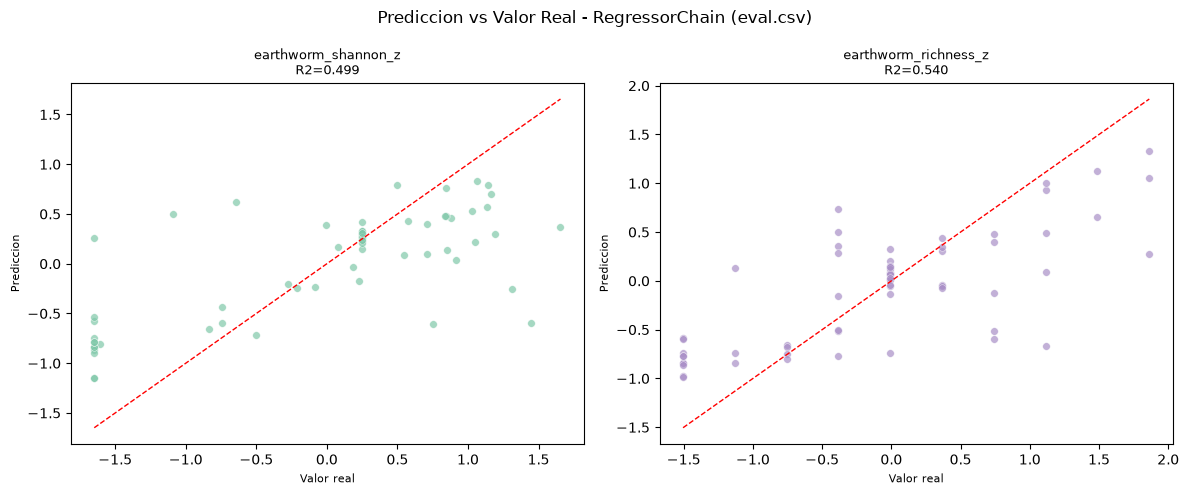

In [8]:

# Evaluacion final
# Cargamos las N cadenas y promediamos sus predicciones sobre eval.csv.

print('Evaluacion final sobre eval.csv')
print('-' * 60)

preds_eval = []
for chain_id in range(N_CHAINS):
    ruta   = os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl')
    cadena = joblib.load(ruta)
    preds_eval.append(cadena.predict(X_eval))

# Promediamos sobre todas las cadenas: shape (N_CHAINS, n_eval, 11) -> (n_eval, 11)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} puntos de Shannon H\'')
print(f'  MAE  global: {mae_global:.4f} puntos de Shannon H\'')

print('\n  R2 por target:')
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for t, r2 in zip(TARGETS, r2_por_target):
    print(f'    {t:30} {r2:.4f}')


# Smoke test con datos reales

print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index
    valores_reales   = y_eval.loc[indices_elegidos].values

    votos = []
    for chain_id in range(N_CHAINS):
        ruta   = os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl')
        cadena = joblib.load(ruta)
        pred   = cadena.predict(df_new_data)
        votos.append(pred)
        # pred es una matriz (3 muestras x 11 targets)
        print(f'  Cadena {chain_id+1:2d} | '
              f'Fila {indices_elegidos[0]}: {pred[0, 2]:.4f} | '
              f'Fila {indices_elegidos[1]}: {pred[1, 2]:.4f} | '
              f'Fila {indices_elegidos[2]}: {pred[2, 2]:.4f}  (earthworm_shannon_z)')

    consenso = np.mean(votos, axis=0)
    print('-' * 60)
    print('  Resultados detallados por muestra (earthworm_shannon_z):')
    print('-' * 60)

    idx_earth = TARGETS.index('earthworm_shannon_z')
    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, idx_earth]
        real_val = y_eval.loc[idx, 'earthworm_shannon_z']
        error    = abs(pred_val - real_val)
        print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
              f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('-' * 60)
    print('\nSmoke test superado. El ensemble de cadenas funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    idx_col = TARGETS.index(tgt)
    yp = y_pred_eval[:, idx_col]
    yt = y_true_eval[:, idx_col]
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - RegressorChain (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()